<a href="https://colab.research.google.com/github/01329582993/Bird-Species-Classification-ML/blob/madina-week3/notebooks/02_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Extraction

Extract image descriptors or other features for model training.

# Color Histogram Feature Extraction
**Dataset:** CUB-200-2011, first 20 bird species

In [ ]:
# Install the dataset downloader
!pip -q install kagglehub

from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Download the CUB-200-2011 dataset
download_path = Path(
    kagglehub.dataset_download("wenewone/cub2002011")
)

DATASET_ROOT = download_path / "CUB_200_2011"
IMAGES_FOLDER = DATASET_ROOT / "images"

print("Downloaded path:", download_path)
print("Dataset root exists:", DATASET_ROOT.exists())
print("Images folder exists:", IMAGES_FOLDER.exists())

100%|██████████| 1.49G/1.49G [00:18<00:00, 87.2MB/s]

Extracting files...


Downloaded path: /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7
Dataset root exists: True
Images folder exists: True


In [ ]:
# Load official class information
classes = pd.read_csv(
    DATASET_ROOT / "classes.txt",
    sep=r"\s+",
    names=["class_id", "class_name"]
)

# Load image IDs and relative paths
images = pd.read_csv(
    DATASET_ROOT / "images.txt",
    sep=r"\s+",
    names=["image_id", "image_path"]
)

# Load the class assigned to each image
image_labels = pd.read_csv(
    DATASET_ROOT / "image_class_labels.txt",
    sep=r"\s+",
    names=["image_id", "class_id"]
)

# Combine all metadata
metadata = images.merge(
    image_labels,
    on="image_id",
    how="inner"
)

metadata = metadata.merge(
    classes,
    on="class_id",
    how="inner"
)

print("All dataset images:", len(metadata))
print("All dataset classes:", metadata["class_id"].nunique())

display(metadata.head())

All dataset images: 11788
All dataset classes: 200


,image_id,image_path,class_id,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross


In [ ]:
# Select class IDs 1 to 20, matching the team preparation notebook
selected_class_ids = (
    classes
    .sort_values("class_id")
    .head(20)["class_id"]
    .tolist()
)

metadata_20 = metadata[
    metadata["class_id"].isin(selected_class_ids)
].copy()

# Add the complete image path
metadata_20["full_image_path"] = metadata_20["image_path"].apply(
    lambda relative_path: IMAGES_FOLDER / relative_path
)

metadata_20 = (
    metadata_20
    .sort_values("image_id")
    .reset_index(drop=True)
)

existing_files = metadata_20["full_image_path"].apply(
    lambda image_path: image_path.exists()
).sum()

print("Selected classes:", metadata_20["class_id"].nunique())
print("Selected images:", len(metadata_20))
print("Existing image files:", existing_files)

print("\nSelected bird species:")
display(
    metadata_20[
        ["class_id", "class_name"]
    ].drop_duplicates()
)

Selected classes: 20
Selected images: 1115
Existing image files: 1115

Selected bird species:


,class_id,class_name
0,1,001.Black_footed_Albatross
60,2,002.Laysan_Albatross
120,3,003.Sooty_Albatross
178,4,004.Groove_billed_Ani
238,5,005.Crested_Auklet
282,6,006.Least_Auklet
323,7,007.Parakeet_Auklet
376,8,008.Rhinoceros_Auklet
424,9,009.Brewer_Blackbird
483,10,010.Red_winged_Blackbird


In [ ]:
# First split: 70% training and 30% remaining
train_data, remaining_data = train_test_split(
    metadata_20,
    test_size=0.30,
    stratify=metadata_20["class_id"],
    random_state=42
)

# Second split: divide the remaining 30% equally
# into 15% validation and 15% testing
validation_data, test_data = train_test_split(
    remaining_data,
    test_size=0.50,
    stratify=remaining_data["class_id"],
    random_state=42
)

# Add split labels
metadata_20["split"] = ""

metadata_20.loc[train_data.index, "split"] = "train"
metadata_20.loc[validation_data.index, "split"] = "val"
metadata_20.loc[test_data.index, "split"] = "test"

split_counts = metadata_20["split"].value_counts()

print("Dataset split:")
print("Training images:", split_counts["train"])
print("Validation images:", split_counts["val"])
print("Testing images:", split_counts["test"])
print("Total images:", split_counts.sum())

# Confirm that every image received a split
assert (metadata_20["split"] != "").all()

print("\nEvery image received a split successfully.")

Dataset split:
Training images: 780
Validation images: 167
Testing images: 168
Total images: 1115

Every image received a split successfully.


## RGB Color Histogram Feature Extraction

A color histogram counts how many pixels belong to different intensity ranges.  
For each image, separate histograms are extracted from the red, green and blue channels.

We use:

- 32 bins for the red channel
- 32 bins for the green channel
- 32 bins for the blue channel
- 96 total features for each image

Each histogram is normalized so that images of different sizes can be compared fairly.

In [ ]:
def extract_color_histogram(image_path, bins=32):
    """
    Extract a normalized RGB color histogram from one image.

    Parameters
    ----------
    image_path : str or Path
        Path of the image.
    bins : int
        Number of histogram bins for each RGB channel.

    Returns
    -------
    numpy.ndarray
        One feature vector containing:
        red histogram + green histogram + blue histogram.
    """

    # Open the image and ensure it has red, green and blue channels
    with Image.open(image_path) as image:
        image_rgb = image.convert("RGB")
        image_array = np.array(image_rgb)

    channel_histograms = []

    # Process the red, green and blue channels separately
    for channel_index in range(3):

        channel_values = image_array[:, :, channel_index]

        histogram, _ = np.histogram(
            channel_values,
            bins=bins,
            range=(0, 256)
        )

        # Convert integers to decimal numbers
        histogram = histogram.astype(np.float32)

        # Normalize the histogram
        histogram_sum = histogram.sum()

        if histogram_sum > 0:
            histogram = histogram / histogram_sum

        channel_histograms.append(histogram)

    # Join the three 32-bin histograms
    feature_vector = np.concatenate(channel_histograms)

    return feature_vector

In [ ]:
# Select the first image from the prepared dataset
sample_row = metadata_20.iloc[0]
sample_image_path = sample_row["full_image_path"]

# Extract its color-histogram features
sample_histogram = extract_color_histogram(
    sample_image_path,
    bins=32
)

print("Bird species:", sample_row["class_name"])
print("Image path:", sample_row["image_path"])
print("Feature-vector length:", len(sample_histogram))
print("First 10 feature values:")
print(sample_histogram[:10])

Bird species: 001.Black_footed_Albatross
Image path: 001.Black_footed_Albatross/Black_Footed_Albatross_0046_18.jpg
Feature-vector length: 96
First 10 feature values:
[0.31579104 0.01518209 0.008      0.0102806  0.01521791 0.01840597
 0.02161791 0.02502687 0.02732537 0.02917612]


In [ ]:
# Split the 96 features back into the three channels
red_histogram = sample_histogram[0:32]
green_histogram = sample_histogram[32:64]
blue_histogram = sample_histogram[64:96]

print("Red histogram sum:", round(float(red_histogram.sum()), 5))
print("Green histogram sum:", round(float(green_histogram.sum()), 5))
print("Blue histogram sum:", round(float(blue_histogram.sum()), 5))

assert len(sample_histogram) == 96
assert np.isclose(red_histogram.sum(), 1.0)
assert np.isclose(green_histogram.sum(), 1.0)
assert np.isclose(blue_histogram.sum(), 1.0)

print("\nColor-histogram function passed all checks.")

Red histogram sum: 1.0
Green histogram sum: 1.0
Blue histogram sum: 1.0

Color-histogram function passed all checks.


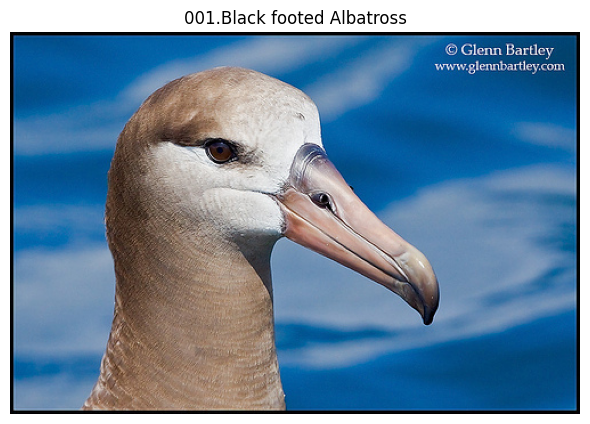

In [ ]:
with Image.open(sample_image_path) as image:
    sample_image = image.convert("RGB")

plt.figure(figsize=(6, 5))
plt.imshow(sample_image)
plt.title(
    sample_row["class_name"].replace("_", " ")
)
plt.axis("off")
plt.tight_layout()
plt.show()

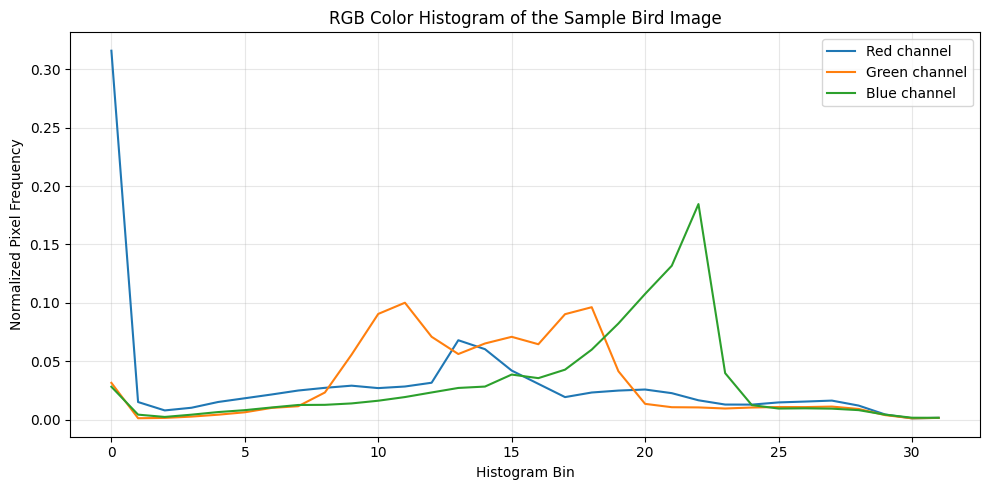

In [ ]:
# The center position of each histogram bin
bin_positions = np.arange(32)

plt.figure(figsize=(10, 5))

plt.plot(
    bin_positions,
    red_histogram,
    label="Red channel"
)

plt.plot(
    bin_positions,
    green_histogram,
    label="Green channel"
)

plt.plot(
    bin_positions,
    blue_histogram,
    label="Blue channel"
)

plt.xlabel("Histogram Bin")
plt.ylabel("Normalized Pixel Frequency")
plt.title("RGB Color Histogram of the Sample Bird Image")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

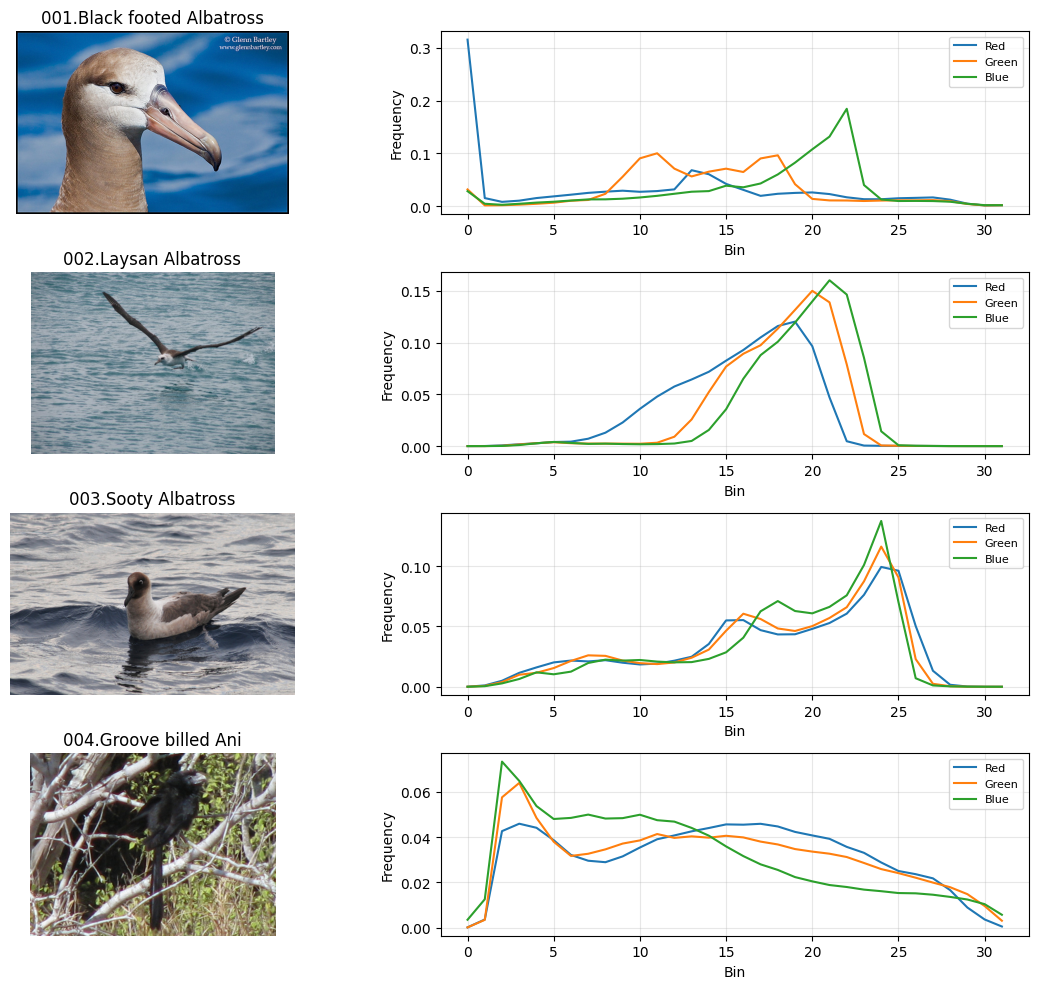

In [ ]:
# Select one image from four different bird classes
sample_images = (
    metadata_20
    .groupby("class_id", group_keys=False)
    .head(1)
    .head(4)
)

plt.figure(figsize=(12, 10))

for position, (_, row) in enumerate(
    sample_images.iterrows(),
    start=1
):
    with Image.open(row["full_image_path"]) as image:
        image_rgb = image.convert("RGB")

    histogram = extract_color_histogram(
        row["full_image_path"],
        bins=32
    )

    plt.subplot(4, 2, position * 2 - 1)
    plt.imshow(image_rgb)
    plt.title(row["class_name"].replace("_", " "))
    plt.axis("off")

    plt.subplot(4, 2, position * 2)

    plt.plot(histogram[0:32], label="Red")
    plt.plot(histogram[32:64], label="Green")
    plt.plot(histogram[64:96], label="Blue")

    plt.xlabel("Bin")
    plt.ylabel("Frequency")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Color Histogram Implementation Conclusion

An RGB color-histogram extraction function was successfully implemented. Each image is converted to RGB and represented using 32 histogram bins for each color channel. The three normalized channel histograms are concatenated to create a 96-dimensional feature vector. Testing and visualization confirmed that the function produces valid and consistent feature vectors for different bird images.

## Extract and Save Color Histogram Feature Vectors

The RGB color-histogram function is applied to all 1,115 selected images. Each image is represented by a normalized 96-dimensional feature vector. Image IDs, class labels and dataset splits are saved with the features so they can later be aligned with HOG features and used for machine-learning training.

In [ ]:
# Extract a 96-dimensional RGB histogram from every selected image

all_color_features = []
failed_images = []

for _, row in tqdm(
    metadata_20.iterrows(),
    total=len(metadata_20),
    desc="Extracting color histograms"
):
    try:
        feature_vector = extract_color_histogram(
            row["full_image_path"],
            bins=32
        )

        all_color_features.append(feature_vector)

    except Exception as error:
        failed_images.append({
            "image_id": row["image_id"],
            "image_path": row["image_path"],
            "error": str(error)
        })

# Convert the feature list into one matrix
X_color = np.asarray(
    all_color_features,
    dtype=np.float32
)

print("Images processed successfully:", len(X_color))
print("Failed images:", len(failed_images))
print("Color feature matrix shape:", X_color.shape)

Extracting color histograms:   0%|          | 0/1115 [00:00<?, ?it/s]

Images processed successfully: 1115
Failed images: 0
Color feature matrix shape: (1115, 96)


In [ ]:
# Labels and identifying information in the same row order as X_color
y_color = metadata_20["class_id"].to_numpy(dtype=np.int32)
image_ids = metadata_20["image_id"].to_numpy(dtype=np.int32)
image_paths = metadata_20["image_path"].astype(str).to_numpy()
split_labels = metadata_20["split"].astype(str).to_numpy()

print("Feature matrix shape:", X_color.shape)
print("Label vector shape:", y_color.shape)
print("Number of classes:", len(np.unique(y_color)))
print("Contains missing values:", np.isnan(X_color).any())
print("Contains infinite values:", np.isinf(X_color).any())

assert X_color.shape == (1115, 96)
assert len(y_color) == 1115
assert len(image_ids) == 1115
assert len(split_labels) == 1115
assert not np.isnan(X_color).any()
assert not np.isinf(X_color).any()

print("\nComplete color feature matrix passed all checks.")

Feature matrix shape: (1115, 96)
Label vector shape: (1115,)
Number of classes: 20
Contains missing values: False
Contains infinite values: False

Complete color feature matrix passed all checks.


In [ ]:
train_mask = split_labels == "train"
validation_mask = split_labels == "val"
test_mask = split_labels == "test"

X_color_train = X_color[train_mask]
y_color_train = y_color[train_mask]

X_color_validation = X_color[validation_mask]
y_color_validation = y_color[validation_mask]

X_color_test = X_color[test_mask]
y_color_test = y_color[test_mask]

print("Training features:", X_color_train.shape)
print("Validation features:", X_color_validation.shape)
print("Testing features:", X_color_test.shape)

assert X_color_train.shape == (780, 96)
assert X_color_validation.shape == (167, 96)
assert X_color_test.shape == (168, 96)

print("\nFeature splits match the prepared dataset.")

Training features: (780, 96)
Validation features: (167, 96)
Testing features: (168, 96)

Feature splits match the prepared dataset.


In [ ]:
from pathlib import Path

output_directory = Path("/content/color_histogram_outputs")
output_directory.mkdir(parents=True, exist_ok=True)

npz_output_path = (
    output_directory /
    "color_histogram_features.npz"
)

np.savez_compressed(
    npz_output_path,

    # Complete aligned data
    X_color=X_color,
    y=y_color,
    image_ids=image_ids,
    image_paths=image_paths,
    splits=split_labels,

    # Ready-to-use dataset splits
    X_train=X_color_train,
    y_train=y_color_train,
    X_validation=X_color_validation,
    y_validation=y_color_validation,
    X_test=X_color_test,
    y_test=y_color_test
)

print("NPZ file saved to:")
print(npz_output_path)

NPZ file saved to:
/content/color_histogram_outputs/color_histogram_features.npz


In [ ]:
# Give clear names to all 96 feature columns

feature_column_names = (
    [f"red_bin_{index:02d}" for index in range(32)]
    + [f"green_bin_{index:02d}" for index in range(32)]
    + [f"blue_bin_{index:02d}" for index in range(32)]
)

color_feature_dataframe = pd.DataFrame(
    X_color,
    columns=feature_column_names
)

feature_metadata = metadata_20[
    [
        "image_id",
        "image_path",
        "class_id",
        "class_name",
        "split"
    ]
].reset_index(drop=True)

color_feature_table = pd.concat(
    [
        feature_metadata,
        color_feature_dataframe
    ],
    axis=1
)

csv_output_path = (
    output_directory /
    "color_histogram_features.csv"
)

color_feature_table.to_csv(
    csv_output_path,
    index=False
)

print("CSV file saved to:")
print(csv_output_path)

print("Saved table shape:", color_feature_table.shape)

display(color_feature_table.head())

CSV file saved to:
/content/color_histogram_outputs/color_histogram_features.csv
Saved table shape: (1115, 101)


,image_id,image_path,class_id,class_name,split,red_bin_00,red_bin_01,red_bin_02,red_bin_03,red_bin_04,...,blue_bin_22,blue_bin_23,blue_bin_24,blue_bin_25,blue_bin_26,blue_bin_27,blue_bin_28,blue_bin_29,blue_bin_30,blue_bin_31
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,0.315791,0.015182,0.008000,0.010281,0.015218,...,0.184561,0.039904,0.012549,0.009618,0.009803,0.009516,0.008251,0.004352,0.001749,0.001690
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,test,0.021440,0.000714,0.000923,0.001149,0.001661,...,0.012131,0.024250,0.044143,0.099435,0.152911,0.170202,0.100226,0.038315,0.121923,0.136298
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,val,0.003775,0.005539,0.011372,0.022127,0.027568,...,0.049527,0.045735,0.041326,0.042657,0.042726,0.039020,0.034415,0.019821,0.007631,0.002029
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,0.000212,0.000318,0.000357,0.000713,0.001918,...,0.056270,0.014829,0.012357,0.024733,0.521186,0.003986,0.001263,0.000742,0.000627,0.000511
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,0.000771,0.002163,0.012808,0.013468,0.004587,...,0.000358,0.000350,0.000898,0.015312,0.070138,0.115646,0.218381,0.229520,0.251519,0.015925


In [ ]:
# Reload NPZ output
loaded_npz = np.load(
    npz_output_path,
    allow_pickle=True
)

# Reload CSV output
loaded_csv = pd.read_csv(csv_output_path)

print("Reloaded NPZ X_color shape:", loaded_npz["X_color"].shape)
print("Reloaded NPZ labels shape:", loaded_npz["y"].shape)
print("Reloaded CSV shape:", loaded_csv.shape)

assert loaded_npz["X_color"].shape == (1115, 96)
assert loaded_npz["y"].shape == (1115,)
assert loaded_csv.shape == (1115, 101)

print("\nSaved feature-vector files were verified successfully.")

Reloaded NPZ X_color shape: (1115, 96)
Reloaded NPZ labels shape: (1115,)
Reloaded CSV shape: (1115, 101)

Saved feature-vector files were verified successfully.


### Saved Color Histogram Features — Conclusion

RGB color-histogram features were extracted successfully from all 1,115 selected bird images. Each image is represented by a normalized 96-dimensional feature vector consisting of 32 red, 32 green and 32 blue histogram values. The complete feature matrix has a shape of 1,115 × 96 and contains no missing or infinite values. The features, class labels, image identifiers and train-validation-test assignments were saved in both compressed NPZ and readable CSV formats for later feature combination and machine-learning experiments.

## Optional Local Binary Pattern (LBP) Feature Extraction

Local Binary Pattern describes image texture by comparing each pixel with its neighboring pixels. The image is first converted to grayscale. An LBP histogram is then calculated and normalized to create a compact texture feature vector.

Parameters used:

- Number of neighboring points: 8
- Radius: 1
- Method: Uniform
- Feature-vector length: 10

In [ ]:
from skimage.feature import local_binary_pattern

print("LBP library imported successfully.")

LBP library imported successfully.


In [ ]:
def extract_lbp_histogram(
    image_path,
    number_of_points=8,
    radius=1
):
    """
    Extract a normalized Local Binary Pattern histogram
    from one image.

    Parameters
    ----------
    image_path : str or Path
        Path to the image.
    number_of_points : int
        Number of neighboring pixels.
    radius : int
        Radius around the center pixel.

    Returns
    -------
    numpy.ndarray
        Normalized LBP histogram.
    """

    # Convert the image to grayscale
    with Image.open(image_path) as image:
        grayscale_image = image.convert("L")
        grayscale_array = np.array(
            grayscale_image,
            dtype=np.uint8
        )

    # Calculate uniform Local Binary Patterns
    lbp_image = local_binary_pattern(
        grayscale_array,
        P=number_of_points,
        R=radius,
        method="uniform"
    )

    # Uniform LBP has P + 2 possible values
    number_of_bins = number_of_points + 2

    histogram, _ = np.histogram(
        lbp_image.ravel(),
        bins=np.arange(0, number_of_bins + 1),
        range=(0, number_of_bins)
    )

    histogram = histogram.astype(np.float32)

    # Normalize the histogram
    histogram_sum = histogram.sum()

    if histogram_sum > 0:
        histogram = histogram / histogram_sum

    return histogram

In [ ]:
sample_lbp_features = extract_lbp_histogram(
    sample_image_path,
    number_of_points=8,
    radius=1
)

print("Bird species:", sample_row["class_name"])
print("LBP feature-vector length:", len(sample_lbp_features))
print("LBP histogram sum:", round(
    float(sample_lbp_features.sum()),
    5
))
print("LBP feature values:")
print(sample_lbp_features)

assert len(sample_lbp_features) == 10
assert np.isclose(sample_lbp_features.sum(), 1.0)

print("\nLBP function passed all checks.")

Bird species: 001.Black_footed_Albatross
LBP feature-vector length: 10
LBP histogram sum: 1.0
LBP feature values:
[0.07259104 0.0880597  0.04210149 0.08025672 0.12038209 0.11104478
 0.07182687 0.09575523 0.14359403 0.17438807]

LBP function passed all checks.


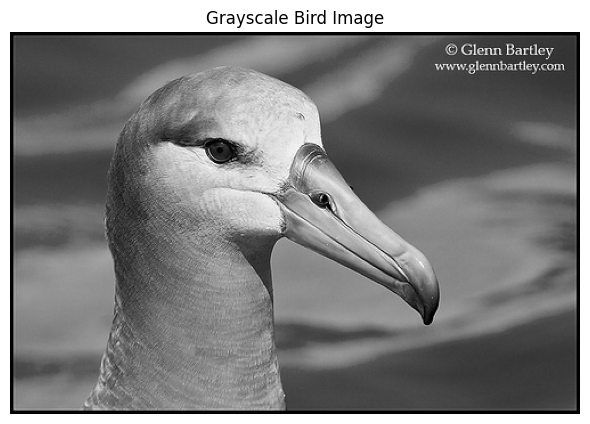

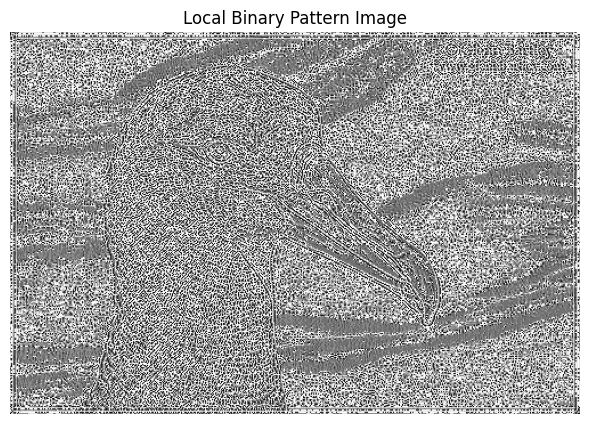

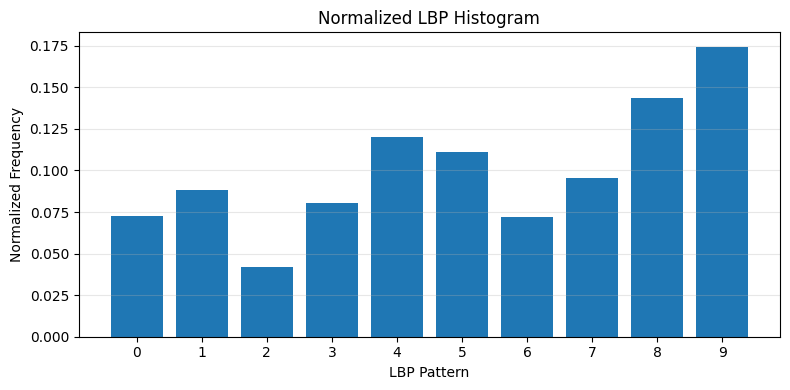

In [ ]:
with Image.open(sample_image_path) as image:
    grayscale_sample = np.array(
        image.convert("L"),
        dtype=np.uint8
    )

sample_lbp_image = local_binary_pattern(
    grayscale_sample,
    P=8,
    R=1,
    method="uniform"
)

plt.figure(figsize=(6, 5))
plt.imshow(grayscale_sample, cmap="gray")
plt.title("Grayscale Bird Image")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(sample_lbp_image, cmap="gray")
plt.title("Local Binary Pattern Image")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(
    np.arange(len(sample_lbp_features)),
    sample_lbp_features
)
plt.xlabel("LBP Pattern")
plt.ylabel("Normalized Frequency")
plt.title("Normalized LBP Histogram")
plt.xticks(np.arange(10))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
all_lbp_features = []
failed_lbp_images = []

for _, row in tqdm(
    metadata_20.iterrows(),
    total=len(metadata_20),
    desc="Extracting LBP features"
):
    try:
        lbp_vector = extract_lbp_histogram(
            row["full_image_path"],
            number_of_points=8,
            radius=1
        )

        all_lbp_features.append(lbp_vector)

    except Exception as error:
        failed_lbp_images.append({
            "image_id": row["image_id"],
            "image_path": row["image_path"],
            "error": str(error)
        })

X_lbp = np.asarray(
    all_lbp_features,
    dtype=np.float32
)

print("Images processed successfully:", len(X_lbp))
print("Failed images:", len(failed_lbp_images))
print("LBP feature matrix shape:", X_lbp.shape)

Extracting LBP features:   0%|          | 0/1115 [00:00<?, ?it/s]

Images processed successfully: 1115
Failed images: 0
LBP feature matrix shape: (1115, 10)


In [ ]:
print("LBP matrix shape:", X_lbp.shape)
print("Number of labels:", len(y_color))
print("Contains missing values:", np.isnan(X_lbp).any())
print("Contains infinite values:", np.isinf(X_lbp).any())

assert X_lbp.shape == (1115, 10)
assert len(y_color) == 1115
assert not np.isnan(X_lbp).any()
assert not np.isinf(X_lbp).any()

print("\nComplete LBP feature matrix passed all checks.")

LBP matrix shape: (1115, 10)
Number of labels: 1115
Contains missing values: False
Contains infinite values: False

Complete LBP feature matrix passed all checks.


In [ ]:
# Use the same split masks created for the color histogram features

X_lbp_train = X_lbp[train_mask]
y_lbp_train = y_color[train_mask]

X_lbp_validation = X_lbp[validation_mask]
y_lbp_validation = y_color[validation_mask]

X_lbp_test = X_lbp[test_mask]
y_lbp_test = y_color[test_mask]

print("LBP training features:", X_lbp_train.shape)
print("LBP validation features:", X_lbp_validation.shape)
print("LBP testing features:", X_lbp_test.shape)

assert X_lbp_train.shape == (780, 10)
assert X_lbp_validation.shape == (167, 10)
assert X_lbp_test.shape == (168, 10)

print("\nLBP feature splits match the prepared dataset.")

LBP training features: (780, 10)
LBP validation features: (167, 10)
LBP testing features: (168, 10)

LBP feature splits match the prepared dataset.


In [ ]:
lbp_output_directory = Path("/content/lbp_outputs")
lbp_output_directory.mkdir(parents=True, exist_ok=True)

lbp_npz_path = lbp_output_directory / "lbp_features.npz"

np.savez_compressed(
    lbp_npz_path,

    # Complete aligned dataset
    X_lbp=X_lbp,
    y=y_color,
    image_ids=image_ids,
    image_paths=image_paths,
    splits=split_labels,

    # Prepared splits
    X_train=X_lbp_train,
    y_train=y_lbp_train,
    X_validation=X_lbp_validation,
    y_validation=y_lbp_validation,
    X_test=X_lbp_test,
    y_test=y_lbp_test
)

print("LBP NPZ file saved to:")
print(lbp_npz_path)

LBP NPZ file saved to:
/content/lbp_outputs/lbp_features.npz


In [ ]:
lbp_column_names = [
    f"lbp_bin_{index:02d}"
    for index in range(10)
]

lbp_feature_dataframe = pd.DataFrame(
    X_lbp,
    columns=lbp_column_names
)

lbp_metadata = metadata_20[
    [
        "image_id",
        "image_path",
        "class_id",
        "class_name",
        "split"
    ]
].reset_index(drop=True)

lbp_feature_table = pd.concat(
    [
        lbp_metadata,
        lbp_feature_dataframe
    ],
    axis=1
)

lbp_csv_path = (
    lbp_output_directory /
    "lbp_features.csv"
)

lbp_feature_table.to_csv(
    lbp_csv_path,
    index=False
)

print("LBP CSV file saved to:")
print(lbp_csv_path)

print("Saved LBP table shape:", lbp_feature_table.shape)

display(lbp_feature_table.head())

LBP CSV file saved to:
/content/lbp_outputs/lbp_features.csv
Saved LBP table shape: (1115, 15)


,image_id,image_path,class_id,class_name,split,lbp_bin_00,lbp_bin_01,lbp_bin_02,lbp_bin_03,lbp_bin_04,lbp_bin_05,lbp_bin_06,lbp_bin_07,lbp_bin_08,lbp_bin_09
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,0.072591,0.088060,0.042101,0.080257,0.120382,0.111045,0.071827,0.095755,0.143594,0.174388
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,test,0.016500,0.038006,0.010280,0.074458,0.158054,0.256458,0.058429,0.072304,0.225244,0.090268
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,val,0.054565,0.065159,0.052807,0.126991,0.226329,0.152254,0.059360,0.068957,0.077406,0.116173
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,0.010072,0.020386,0.008323,0.045041,0.078627,0.179287,0.038564,0.036289,0.554053,0.029359
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,0.045699,0.095985,0.046899,0.098799,0.107919,0.133455,0.101065,0.101701,0.120830,0.147647


In [ ]:
loaded_lbp_npz = np.load(
    lbp_npz_path,
    allow_pickle=True
)

loaded_lbp_csv = pd.read_csv(
    lbp_csv_path
)

print(
    "Reloaded NPZ LBP shape:",
    loaded_lbp_npz["X_lbp"].shape
)

print(
    "Reloaded NPZ labels shape:",
    loaded_lbp_npz["y"].shape
)

print(
    "Reloaded CSV shape:",
    loaded_lbp_csv.shape
)

assert loaded_lbp_npz["X_lbp"].shape == (1115, 10)
assert loaded_lbp_npz["y"].shape == (1115,)
assert loaded_lbp_csv.shape == (1115, 15)

print("\nSaved LBP feature files were verified successfully.")

Reloaded NPZ LBP shape: (1115, 10)
Reloaded NPZ labels shape: (1115,)
Reloaded CSV shape: (1115, 15)

Saved LBP feature files were verified successfully.


### LBP Feature Extraction Conclusion

The optional Local Binary Pattern feature extraction was successfully implemented. Each selected bird image was converted to grayscale and represented using a normalized 10-dimensional uniform LBP histogram. Features were extracted from all 1,115 images without failures, missing values or infinite values. The LBP feature matrix and its train-validation-test splits were saved in NPZ and CSV formats for possible later texture-based experiments.